IMPORT LIBRARIES

In [ ]:
import pandas as pd
import re
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

 LOAD DATASET

In [ ]:
file_path = "/content/data-đồ-án.xlsm"

df = pd.read_excel(file_path, engine="openpyxl")

df = df[["Comment", "Label", "Rate"]].dropna()
df["Label"] = df["Label"].astype(str).str.strip().str.upper()

print("Dataset shape:", df.shape)
print("\nLabel distribution:")
print(df["Label"].value_counts())

Dataset shape: (31460, 3)

Label distribution:
Label
POS    20093
NEG     6669
NEU     4698
Name: count, dtype: int64


TEXT PREPROCESSING

In [ ]:
def preprocess(text):
    text = str(text).lower()

    # Chuẩn hóa một số từ viết tắt phổ biến trong comment tiếng Việt
    replacements = {
        " ko ": " không ",
        " k ": " không ",
        " kh ": " không ",
        " hok ": " không ",
        " kg ": " không ",
        " dc ": " được ",
        " đc ": " được ",
        " sp ": " sản phẩm ",
        " shop ": " shop ",
        " ok ": " tốt ",
        " oke ": " tốt ",
    }

    text = " " + text + " "
    for k, v in replacements.items():
        text = text.replace(k, v)

    # Bỏ ký tự đặc biệt, giữ chữ tiếng Việt
    text = re.sub(r"[^\w\sÀ-ỹ]", " ", text)

    # Bỏ số
    text = re.sub(r"\d+", " ", text)

    # Giảm ký tự lặp quá nhiều: đẹpppp -> đẹpp
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)

    # Chuẩn hóa khoảng trắng
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_text"] = df["Comment"].apply(preprocess)

print(df[["Comment", "clean_text", "Label"]].head())

                       Comment                  clean_text Label
0               Áo bao đẹp ạ!!                áo bao đẹp ạ   POS
1                  Tuyệt vời !                   tuyệt vời   POS
2   2day ao khong giong trong.    day ao khong giong trong   NEG
3  Mùi thơm,bôi lên da mềm da.  mùi thơm bôi lên da mềm da   POS
4            Vải đẹp, dày dặn.             vải đẹp dày dặn   POS


TRAIN / TEST SPLIT

In [ ]:
X = df["clean_text"]
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

print("\nTrain label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Train size: 25168
Test size: 6292

Train label distribution:
Label
POS    16074
NEG     5335
NEU     3759
Name: count, dtype: int64

Test label distribution:
Label
POS    4019
NEG    1334
NEU     939
Name: count, dtype: int64


 FEATURE ENGINEERING

In [ ]:
word_tfidf = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 3),
    max_features=30000,
    min_df=2,
    sublinear_tf=True
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    max_features=50000,
    min_df=2,
    sublinear_tf=True
)

features = FeatureUnion([
    ("word_tfidf", word_tfidf),
    ("char_tfidf", char_tfidf)
])

print("Feature engineering setup completed.")

Feature engineering setup completed.


BUILD LOGISTIC REGRESSION MODEL

In [ ]:
model = OneVsRestClassifier(
    LogisticRegression(
        solver="liblinear",
        max_iter=1000
    )
)

pipeline = Pipeline([
    ("features", features),
    ("model", model)
])

print("Pipeline created successfully.")

Pipeline created successfully.


GRID SEARCH

In [ ]:
# class_weight=None thường tối ưu accuracy
# class_weight='balanced' thường cải thiện NEU/NEG nhưng đôi khi giảm accuracy

param_grid = {
    "model__estimator__C": [0.5, 1, 2, 5, 10],
    "model__estimator__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Grid Search completed.")
print("Best Parameters:", grid.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Grid Search completed.
Best Parameters: {'model__estimator__C': 1, 'model__estimator__class_weight': None}


EVALUATION

In [ ]:
y_pred = best_model.predict(X_test)

print("\n==== MODEL LOGISTIC REGRESSION ====")
print("Best Parameters:", grid.best_params_)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


==== MODEL LOGISTIC REGRESSION ====
Best Parameters: {'model__estimator__C': 1, 'model__estimator__class_weight': None}
Accuracy: 0.7924348378893833

Confusion Matrix:
[[1045  118  171]
 [ 310  168  461]
 [ 136  110 3773]]

Classification Report:
              precision    recall  f1-score   support

         NEG     0.7009    0.7834    0.7398      1334
         NEU     0.4242    0.1789    0.2517       939
         POS     0.8565    0.9388    0.8958      4019

    accuracy                         0.7924      6292
   macro avg     0.6605    0.6337    0.6291      6292
weighted avg     0.7590    0.7924    0.7666      6292



Calculate Params, Model Size, Inference Time, FPS

In [ ]:
import time
import os
import joblib

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. PERFORMANCE METRICS

main_metric = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

# 2. PARAMETERS / PARAMS

ovr_model = best_model.named_steps["model"]

total_params = 0

for estimator in ovr_model.estimators_:
    total_params += estimator.coef_.size
    total_params += estimator.intercept_.size

params_million = total_params / 1_000_000

# 3. MODEL SIZE

model_path = "logistic_regression_emotion_model.pkl"
joblib.dump(best_model, model_path)

model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

# 4. FPS / INFERENCE TIME

X_test_list = list(X_test)

start_time = time.time()
_ = best_model.predict(X_test_list)
end_time = time.time()

total_time = end_time - start_time
num_samples = len(X_test_list)

fps = num_samples / total_time
inference_time_ms = (total_time / num_samples) * 1000

# 5. ESTIMATED FLOPs
# Logistic Regression + TF-IDF approximate

num_features = best_model.named_steps["features"].transform(X_train[:1]).shape[1]
num_classes = len(best_model.named_steps["model"].estimators_)

flops_per_sample = 2 * num_features * num_classes
flops_g = flops_per_sample / 1_000_000_000

# 6. PRINT VALUES

print("Main Metric / Accuracy:", round(main_metric, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

print("Params:", f"{params_million:.4f} M")
print("FPS:", f"{fps:.2f}")

print("Parameters:", f"{params_million:.4f} M")
print("Model Size:", f"{model_size_mb:.2f} MB")
print("FLOPs:", f"{flops_g:.6f} G")
print("FPS / Inference Time:", f"{fps:.2f} FPS / {inference_time_ms:.4f} ms")

Main Metric / Accuracy: 0.7924
Precision: 0.6605
Recall: 0.6337
F1-score: 0.6291
Params: 0.1364 M
FPS: 10597.38
Parameters: 0.1364 M
Model Size: 2.77 MB
FLOPs: 0.000273 G
FPS / Inference Time: 10597.38 FPS / 0.0944 ms


Confusion Matrix:
[[1045  118  171]
 [ 310  168  461]
 [ 136  110 3773]]


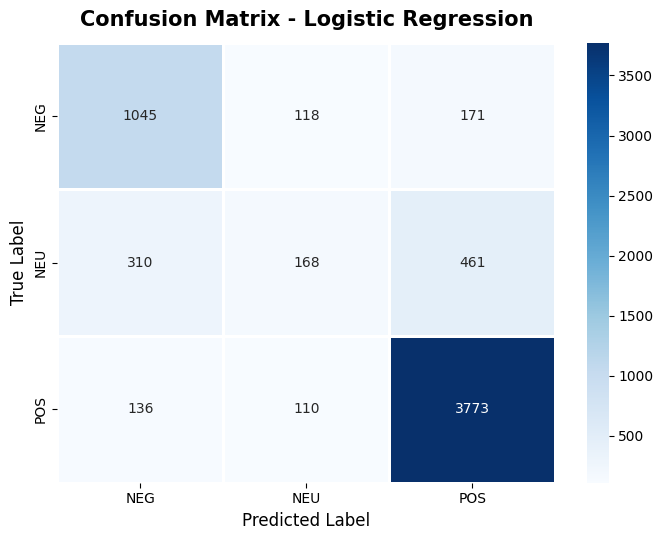

In [ ]:
# ==========================================
# CONFUSION MATRIX FOR LOGISTIC REGRESSION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# ==========================================
# 1. PREDICT ON TEST SET
# ==========================================

y_pred = best_model.predict(X_test)

# ==========================================
# 2. CREATE CONFUSION MATRIX
# ==========================================

labels = ["NEG", "NEU", "POS"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

print("Confusion Matrix:")
print(cm)

# ==========================================
# 3. PLOT  CONFUSION MATRIX
# ==========================================

plt.figure(figsize=(7, 5.5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.8,
    linecolor="white",
    cbar=True
)

plt.title("Confusion Matrix - Logistic Regression", fontsize=15, fontweight="bold", pad=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)

plt.tight_layout()
plt.show()

Đã lưu model tại: Saved_logistic_model/logistic_regression_model.pkl
{'Model': 'Logistic Regression', 'Accuracy': 0.7924, 'Precision': 0.6605, 'Recall': 0.6337, 'F1-score': 0.6291, 'Params': 136380, 'Params(M)': 0.1364, 'Model Size(MB)': 2.7653, 'FPS': 17328.69, 'Inference Time(ms/sample)': 0.0577}
Đã lưu metrics CSV: Saved_logistic_model/metrics.csv
Đã lưu metrics JSON: Saved_logistic_model/metrics.json
Đã lưu classification report: Saved_logistic_model/classification_report.txt


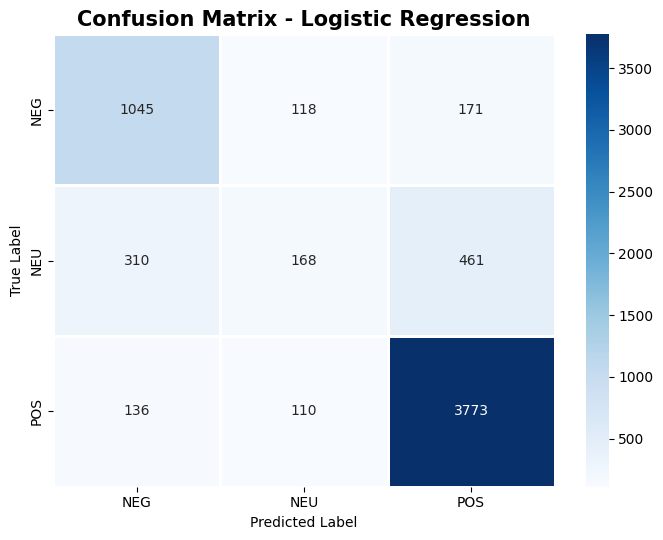

Đã lưu confusion matrix: Saved_logistic_model/confusion_matrix.png


In [ ]:
import os
import json
import joblib
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# =========================
# 1. TẠO THƯ MỤC LƯU KẾT QUẢ
# =========================
SAVE_DIR = "Saved_logistic_model"
os.makedirs(SAVE_DIR, exist_ok=True)

# =========================
# 2. LƯU MODEL
# =========================
model_path = os.path.join(SAVE_DIR, "logistic_regression_model.pkl")
joblib.dump(best_model, model_path)

print("Đã lưu model tại:", model_path)

# =========================
# 3. DỰ ĐOÁN TEST SET
# =========================
y_pred = best_model.predict(X_test)

# =========================
# 4. TÍNH METRICS
# =========================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

# Params
ovr_model = best_model.named_steps["model"]

total_params = 0
for estimator in ovr_model.estimators_:
    total_params += estimator.coef_.size
    total_params += estimator.intercept_.size

params_million = total_params / 1_000_000

# Model size
model_size_mb = os.path.getsize(model_path) / (1024 * 1024)

# FPS
X_test_list = list(X_test)

start_time = time.time()
_ = best_model.predict(X_test_list)
end_time = time.time()

total_time = end_time - start_time
fps = len(X_test_list) / total_time
inference_time_ms = (total_time / len(X_test_list)) * 1000

metrics = {
    "Model": "Logistic Regression",
    "Accuracy": round(accuracy, 4),
    "Precision": round(precision, 4),
    "Recall": round(recall, 4),
    "F1-score": round(f1, 4),
    "Params": int(total_params),
    "Params(M)": round(params_million, 4),
    "Model Size(MB)": round(model_size_mb, 4),
    "FPS": round(fps, 2),
    "Inference Time(ms/sample)": round(inference_time_ms, 4)
}

print(metrics)

# =========================
# 5. LƯU METRICS CSV + JSON
# =========================
metrics_df = pd.DataFrame([metrics])

metrics_csv_path = os.path.join(SAVE_DIR, "metrics.csv")
metrics_json_path = os.path.join(SAVE_DIR, "metrics.json")

metrics_df.to_csv(metrics_csv_path, index=False)

with open(metrics_json_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=4)

print("Đã lưu metrics CSV:", metrics_csv_path)
print("Đã lưu metrics JSON:", metrics_json_path)

# =========================
# 6. LƯU CLASSIFICATION REPORT
# =========================
report = classification_report(y_test, y_pred, digits=4)

report_path = os.path.join(SAVE_DIR, "classification_report.txt")

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print("Đã lưu classification report:", report_path)

# =========================
# 7. LƯU CONFUSION MATRIX
# =========================
labels = ["NEG", "NEU", "POS"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7, 5.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.8,
    linecolor="white"
)

plt.title("Confusion Matrix - Logistic Regression", fontsize=15, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

cm_path = os.path.join(SAVE_DIR, "confusion_matrix.png")
plt.savefig(cm_path, dpi=300)
plt.show()

print("Đã lưu confusion matrix:", cm_path)